# Session 1 · Part 2 — Programming Model: MPI Basics

**10:30 – 11:00**

---

MPI is not a library. It is an *interface specification*, maintained by the MPI
Forum, with several independent implementations — Open MPI, MPICH, vendor
variants. That is why code written in 1996 still compiles and runs on machines
that did not exist then. In Python we reach it through `mpi4py`.

In thirty minutes we will cover the three things you need in order to read the
NetQMPI code in notebook 03:

1. **SPMD** — one source file, N processes
2. **Point-to-point** — `send` / `recv`, and the deadlock they cause
3. **Collectives** — `Scatter`, `Gather`, `Reduce`

In [ ]:
import os
os.environ["OMPI_ALLOW_RUN_AS_ROOT"] = "1"
os.environ["OMPI_ALLOW_RUN_AS_ROOT_CONFIRM"] = "1"
print("ready")

---
## 1 · The SPMD paradigm

**Single Program, Multiple Data.** You write *one* source file. The launcher
starts N copies of it as independent processes and injects a distinct identifier
into each. The program reads that identifier and decides which branch of its own
logic to run.

```
                       ┌──────────────┐
                       │  script.py   │   one source file
                       └──────┬───────┘
                              │
                      mpirun -n 3
                              │
              ┌───────────────┼───────────────┐
              ▼               ▼               ▼
        rank 0, size 3  rank 1, size 3  rank 2, size 3
```

Two pieces of vocabulary do all the work:

**Rank** — an integer in `[0, size-1]` identifying a process *within a
communicator*. It is a logical label. It is not a node number, not an OS process
id, not a network address. That is precisely its value: your program reasons
about ranks, and the runtime decides where they physically land.

**Communicator** — a group of processes plus an isolated communication context.
Every message travels inside one. At start-up you get `MPI.COMM_WORLD`,
containing every process launched.

Think of the communicator as a **virtualisation layer**: it shows you
participants numbered 0 to N−1 on top of what is really a heterogeneous pile of
hardware. Remember this framing — NetQMPI's `QMPICommunicator` does exactly the
same thing for QPUs.

> **Why SPMD and not one file per role?** Writing `app_alice.py`, `app_bob.py`,
> `app_charlie.py` seems more natural at first and collapses immediately: going
> from three participants to four means writing a new file *and* editing the
> existing ones. SPMD decouples the code from the process count. That decoupling
> is the single central argument of NetQMPI, so it is worth feeling it here
> first.

### Exercise 1 — "Hello world" with MPI

Complete the two `TODO`s so that every process announces itself.

In [ ]:
%%writefile ex1_hello.py
from mpi4py import MPI

comm = MPI.COMM_WORLD

# TODO 1: ask the communicator who this process is, and how many there are.
#         Look for two methods on `comm` whose names start with "Get_".
rank = None   # TODO
size = None   # TODO

name = MPI.Get_processor_name()
print(f"I am rank {rank} of {size}, on {name}", flush=True)

# TODO 2: rank 0 is the conventional coordinator. Make ONLY rank 0 print
#         one extra line: "rank 0 here: I am the coordinator".
#         Every other rank must stay silent.

In [ ]:
!mpirun -n 4 python3 -u ex1_hello.py

**Check:** four "I am rank..." lines in a random order, and exactly one
coordinator line.

Run it a second time and watch the order change. Then change `-n 4` to `-n 7`
without touching the script. That is the whole point of SPMD: the source is
independent of the process count.

---
## 2 · Point-to-point communication

The elementary operation: one rank sends a message, another receives it.
Everything else — collectives included — can be built on top.

A send names its **destination**; a receive names its **source**. A receive matches a send only if source,
destination and communicator all agree.

In [ ]:
%%writefile p2p_demo.py
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

if rank == 0:
    payload = {"iteration": 7, "residual": 1e-6}
    comm.send(payload, dest=1)
    print("rank 0: sent", payload, flush=True)
elif rank == 1:
    payload = comm.recv(source=0)
    print("rank 1: received", payload, flush=True)

In [ ]:
!mpirun -n 2 python3 -u p2p_demo.py

> ### The lowercase / uppercase trap in mpi4py
> 
> `mpi4py` offers every operation twice, and the difference is not cosmetic:
> 
> | Form | Example | What it does |
> |---|---|---|
> | **lowercase** | `comm.send(obj, ...)` | Any Python object, serialised with `pickle`. Convenient, slow. |
> | **uppercase** | `comm.Send(buf, ...)` | A buffer exposing the memory protocol — typically a NumPy array. No copy, fast. |
> 
> Use lowercase for small control messages, uppercase for data. Confusing them is
> the number-one beginner mistake, because the program works either way and runs
> ten times slower.

### Blocking, and the deadlock it causes

`send` and `recv` are **blocking**: they do not return until it is safe to reuse
the buffer. Now consider the most natural way to write a two-way exchange —
everyone sends first, then receives:

In [ ]:
%%writefile deadlock.py
from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
other = 1 - rank

# A big message, so the MPI library cannot quietly buffer it for us.
data = np.ones(4_000_000, dtype=np.float64)
recv = np.empty(4_000_000, dtype=np.float64)

print(f"rank {rank}: about to send", flush=True)
comm.Send(data, dest=other)      # <-- both ranks block here, forever
comm.Recv(recv, source=other)    # <-- neither rank ever arrives here
print(f"rank {rank}: done", flush=True)

In [ ]:
# `timeout` kills it after 10 s, so the notebook cannot hang.
# Exit code 124 is the timeout's way of saying "it was still running".
!timeout 10 mpirun -n 2 python3 -u deadlock.py; echo "exit code: $?"

---
### Exercise 2.1. Doing it by hand, once — so we never do it again

Before meeting the collectives, let us solve a real problem with nothing but
`Send` and `Recv`: **add two vectors, splitting the work across ranks.**

This is the canonical data-decomposition problem, and the shape is always the
same: hand out the chunks, compute locally, collect the results. Read the code
carefully — three of the details it has to get right are exactly the details a
collective will get right for you.

In [ ]:
%%writefile vectoradd_manual.py
from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
comm_size = comm.Get_size()

VECTOR_SIZE = 3600
ROOT_RANK = 0
assert VECTOR_SIZE % comm_size == 0, "Vector size is not divisible by the number of processors"
chunk_size = VECTOR_SIZE // comm_size

# Every rank holds a chunk -- the root included.
a_local = np.empty(chunk_size, dtype=np.float64)
b_local = np.empty(chunk_size, dtype=np.float64)

if rank == ROOT_RANK:
    a = np.arange(VECTOR_SIZE, dtype=np.float64)
    b = np.ones(VECTOR_SIZE, dtype=np.float64)
    result = np.empty(VECTOR_SIZE, dtype=np.float64)

    # The root keeps its own chunk by copying it. NEVER Send to yourself:
    # there is no matching Recv, so the program deadlocks as soon as the
    # message is too big for the library to buffer silently.
    a_local[:] = a[:chunk_size]
    b_local[:] = b[:chunk_size]

    # Hand out the rest, one chunk per rank. Tags keep `a` and `b` apart.
    for other_rank in range(1, comm_size):
        lo, hi = chunk_size * other_rank, chunk_size * (other_rank + 1)
        comm.Send(a[lo:hi], dest=other_rank, tag=0)
        comm.Send(b[lo:hi], dest=other_rank, tag=1)
else:
    result = None
    comm.Recv(a_local, source=ROOT_RANK, tag=0)
    comm.Recv(b_local, source=ROOT_RANK, tag=1)

# The only line here that is actual computation.
result_local = a_local + b_local

# And now collect everything back, by hand as well.
if rank == ROOT_RANK:
    result[:chunk_size] = result_local
    for other_rank in range(1, comm_size):
        lo, hi = chunk_size * other_rank, chunk_size * (other_rank + 1)
        comm.Recv(result[lo:hi], source=other_rank, tag=2)
    print("first 5 elements:", result[:5], flush=True)
    print("correct:", np.allclose(result, np.arange(VECTOR_SIZE) + 1.0), flush=True)
else:
    comm.Send(result_local, dest=ROOT_RANK, tag=2)

In [ ]:
!mpirun -n 4 python3 -u vectoradd_manual.py

It works — and it is about thirty lines to add two vectors. **The index arithmetic is yours to get right.** `chunk_size * other_rank` up to
`chunk_size * (other_rank + 1)`, consistently, in three separate places.

---
## 3 · Collective operations

A **collective** involves *every* process in a communicator. All of them must
call it; if one does not, the program hangs. In exchange you get one line of code
instead of a loop, and the implementation is free to use a smart algorithm —
binomial trees, ring algorithms — rather than the naive fan-out you would write.

The four fundamentals, classified by **what they do to the data**. This
classification is the one that matters, because it predicts exactly which of them
survive into the quantum world:

| Operation | Action | Before → after |
|---|---|---|
| `Bcast` | **copies** | root has `A` → everyone has `A` |
| `Scatter` | **moves** | root has `[A B C D]` → rank *i* has the *i*-th piece |
| `Gather` | **moves** | rank *i* has a piece → root has `[A B C D]` |
| `Reduce` | **combines** | rank *i* has `x_i` → root has `x_0 ⊕ x_1 ⊕ ...` |

Also worth knowing: `Allgather` and `Allreduce` leave the result on *every* rank
rather than only the root; `Barrier` synchronises without moving data; and
`Scatterv` / `Gatherv` handle chunks of unequal size, which you need whenever the
element count is not divisible by the process count.

> **Remember the middle column.** In notebook 03: the *moving* ones survive
> intact, `Bcast` is **physically impossible** (no-cloning), and `Reduce` would
> require a measurement, which destroys the superposition.

### The four collectives, visually

Each figure shows the same four ranks **before** and **after** the call. Rows are
ranks, the root is highlighted, and every coloured block is one chunk of data.
Follow the colour of the arrows: it tells you *which* piece of data travels
where.

In `scatter_gather.py` further down, with `-n 4` and three elements per rank,
**A** is `[0 1 2]`, **B** is `[3 4 5]`, **C** is `[6 7 8]` and **D** is `[9 10 11]`.

#### `Bcast` — copies

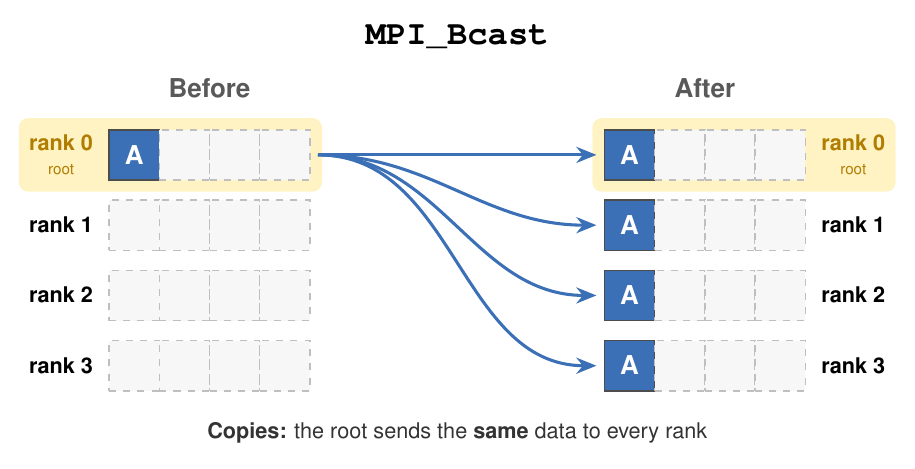

Every arrow is the same colour: nobody receives a *piece* of `A`, everybody
receives *all* of it. After the call `A` exists four times. Keep that in mind for
notebook 03.

#### `Scatter` — moves

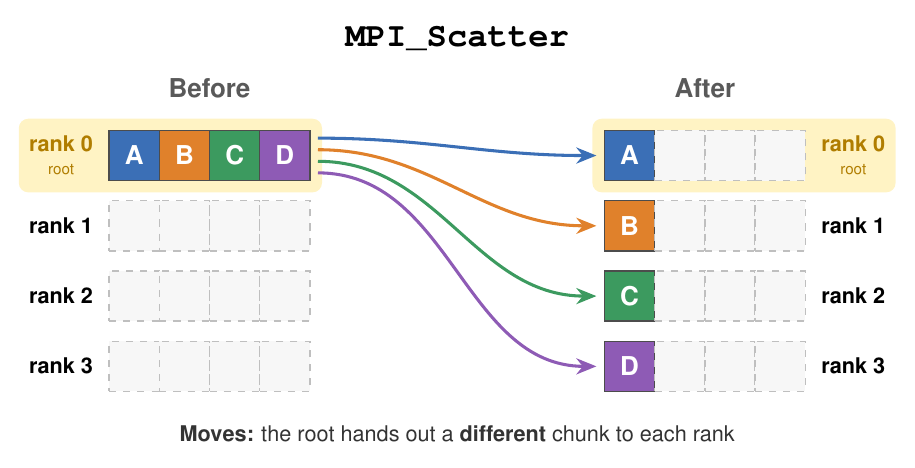

One colour per arrow: the root's buffer is cut into equal chunks and rank *i*
gets the *i*-th one. The root keeps chunk `A` for itself — no self-send needed.

#### `Gather` — moves

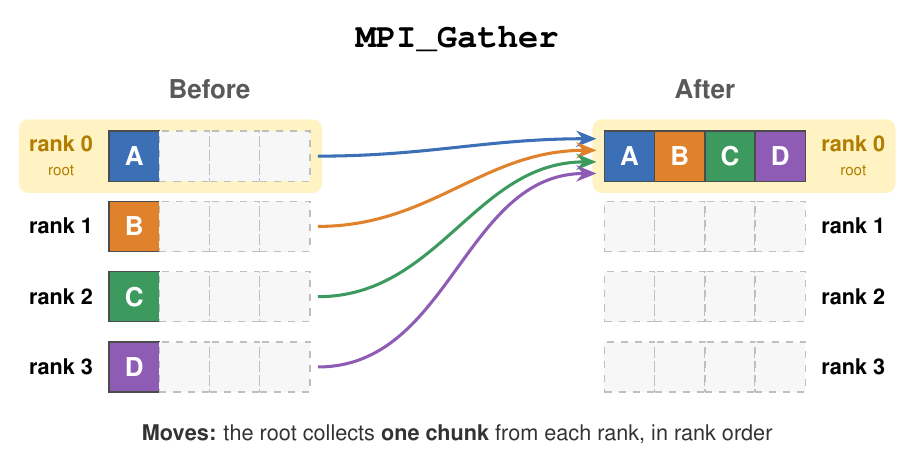

The exact inverse of `Scatter`. The chunks are laid out in the root's buffer
**in rank order**, regardless of which rank finished first.

#### `Reduce` — combines

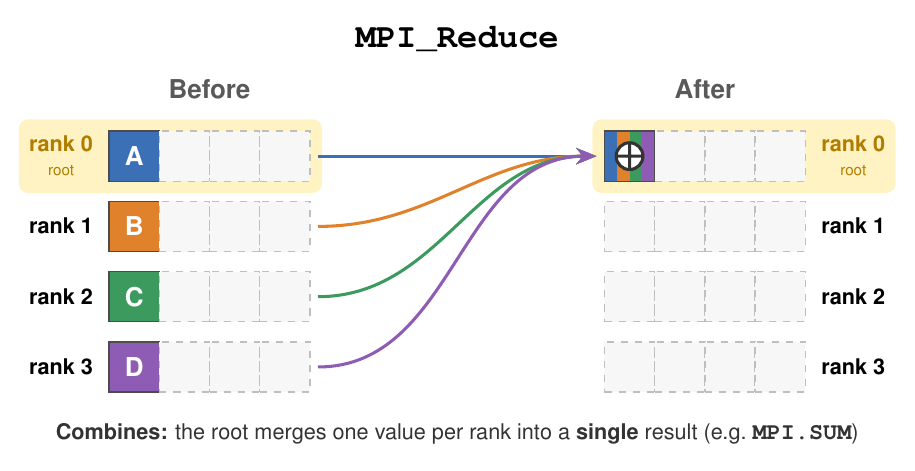

Same input as `Gather`, very different output: instead of four chunks side by
side, the root ends up with **one** value of the same size as each input, built
with the operator you pass (`MPI.SUM`, `MPI.MAX`, ...). The individual inputs
are no longer recoverable from the result.


In [ ]:
%%writefile collectives.py
from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
rank, size = comm.Get_rank(), comm.Get_size()

# --- Bcast: the root copies one value to everybody -------------------------
config = {"tolerance": 1e-8} if rank == 0 else None
config = comm.bcast(config, root=0)
print(f"[bcast]   rank {rank} got {config}", flush=True)

comm.Barrier()

# --- Scatter: the root hands out one chunk per rank ------------------------
sendbuf = np.arange(size * 3, dtype=np.float64) if rank == 0 else None
chunk = np.empty(3, dtype=np.float64)
comm.Scatter(sendbuf, chunk, root=0)
print(f"[scatter] rank {rank} got {chunk}", flush=True)

comm.Barrier()

# --- Reduce: combine one value per rank into one value at the root ---------
mine = np.array(float(rank))
total = np.empty(1) if rank == 0 else None
comm.Reduce(mine, total, op=MPI.SUM, root=0)
if rank == 0:
    print(f"[reduce]  sum of all ranks = {total[0]}", flush=True)

In [ ]:
!mpirun -n 4 python3 -u collectives.py

### Scatter and Gather, up close

`Scatter` and `Gather` are exact inverses, and they are the pair you will reach
for again and again. Here they are on an array small enough to print, so you can
watch the data move.

Three rules govern every call, and getting any of them wrong is the usual cause
of a confusing crash:

1. **The receive buffer must already exist**, and it must be exactly the size of
   one chunk. MPI writes into memory you provide; it does not allocate for you.
2. **Non-root ranks pass `None`** as the send buffer. Only the root holds the
   full array.
3. **Chunks are assigned in rank order.** Rank *i* always gets the *i*-th slice —
   the same tiling you had to compute by hand in exercise 2.1.

In [ ]:
%%writefile scatter_gather.py
from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
rank, size = comm.Get_rank(), comm.Get_size()

PER_RANK = 3
TOTAL = PER_RANK * size            # the problem grows with the rank count

# --- the root owns the whole array; the others own nothing yet -------------
if rank == 0:
    data = np.arange(TOTAL, dtype=np.float64)
    print(f"[root]   before scatter : {data}", flush=True)
else:
    data = None                    # non-root ranks MUST pass None

# --- every rank supplies a receive buffer of exactly one chunk -------------
chunk = np.empty(PER_RANK, dtype=np.float64)

comm.Scatter(data, chunk, root=0)

# A Barrier separates the two phases so the output is grouped. It does NOT
# order the lines within a phase -- MPI never orders stdout.
comm.Barrier()
print(f"[rank {rank}] received       : {chunk}", flush=True)

# --- purely local work: no MPI, no knowledge of any other rank -------------
chunk *= 10

# --- collect the pieces back, in rank order --------------------------------
gathered = np.empty(TOTAL, dtype=np.float64) if rank == 0 else None
comm.Gather(chunk, gathered, root=0)

comm.Barrier()
if rank == 0:
    print(f"[root]   after gather   : {gathered}", flush=True)

In [ ]:
!mpirun -n 4 python3 -u scatter_gather.py

Read the first and last lines together: `[0 1 2 ... 11]` went out, `[0 10 20 ...
110]` came back, in the right order, and no rank ever saw more than three
elements.

Compare that with section 2.1. The chunk boundaries, the tags, the self-send trap:
gone. Two calls.

### Exercise 2.2 — The same thing, with collectives

Now rewrite `vectoradd_manual.py` using collectives. Identical result, and the
three chores from section 3 all disappear: no self-send to avoid, no tags to
juggle, no index arithmetic.

Count the lines when you are done, and compare.

In [ ]:
%%writefile ex2_vecadd.py
from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
rank, size = comm.Get_rank(), comm.Get_size()

N = 1_000_000
assert N % size == 0, "use Scatterv when N is not divisible by size"
local_n = N // size

# Only the root materialises the full vectors. Everyone else passes None.
if rank == 0:
    a = np.arange(N, dtype=np.float64)
    b = np.ones(N, dtype=np.float64)
    c = np.empty(N, dtype=np.float64)
else:
    a = b = c = None

a_local = np.empty(local_n, dtype=np.float64)
b_local = np.empty(local_n, dtype=np.float64)

# TODO 1: hand out one chunk of `a` and one chunk of `b` to every rank.
#         Use the uppercase form — these are NumPy buffers, not Python objects.
# comm.???(a, a_local, root=0)
# comm.???(b, b_local, root=0)

# TODO 2: the local computation. One line, no MPI involved.
c_local = None   # TODO

# TODO 3: collect every rank's result back into `c` on the root.
# comm.???(c_local, c, root=0)

if rank == 0:
    expected = np.arange(N) + 1.0
    print("correct:", np.allclose(c, expected), flush=True)

In [ ]:
!mpirun -n 4 python3 -u ex2_vecadd.py

---
## Recap before the quantum half

Four ideas travel with us into notebook 03:

1. **SPMD** — one source file, rank selects the behaviour. NetQMPI keeps this
   exactly, right down to `netqmpi -n 3 script.py` mirroring `mpirun -n 3`.
2. **Communicator** — a logical view over physical resources. `QMPICommunicator`
   plays the same role over QPUs.
3. **Copy / move / combine** — the classification of collectives. Copying is
   about to become illegal.
4. **$T = \alpha + \beta n$** — messages have a fixed cost. Entangled pairs have
   a much larger one, and unlike a classical message they are *consumed* on use
   and they *expire*.

**On to notebook 03.**